In [ ]:
pip install --upgrade scikit-learn

In [ ]:
!pip install pandas==2.0.3

In [ ]:
!pip install tensorflow==2.16.1

In [ ]:
!pip install scikeras

IMPORTS

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense, InputLayer
from keras.metrics import Recall, Precision
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import pandas as pd
#from scikeras.wrappers import KerasClassifier
#import scikeras
import tensorflow as tf
import sklearn

In [ ]:
pd.__version__, tf.__version__, sklearn.__version__, scikeras.__version__,

NameError: name 'scikeras' is not defined

CARREGAR O DATASET

In [ ]:
dataset = pd.read_csv("loan_approval_dataset.csv")
dataset.columns = dataset.columns.str.strip()
# Aplicar strip apenas nas colunas de texto
dataset = dataset.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
dataset.shape

(4269, 13)

In [ ]:
dataset.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


AGRUPAR AS COLUNAS DE ASSETS EM UMA ÚNICA COLUNA

In [ ]:
#dataset.insert(len(dataset.columns) - 1,'total_assets_value',
#    dataset['residential_assets_value'] +
#    dataset['commercial_assets_value'] +
#    dataset['luxury_assets_value'] +
#    dataset['bank_asset_value']
#)

#dataset.drop(['loan_id','self_employed','residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'], axis=1, inplace=True)

dataset.drop(['loan_id','self_employed'], axis=1, inplace=True)

In [ ]:
dataset.head()

,no_of_dependents,education,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


TRANSFORMAR OS DADOS CATEGÓRICOS E NUMÉRICOS

In [ ]:
classe = dataset['loan_status'].values
previsores = dataset.iloc[:,:-1]

numeric_features = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
                    'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
categorical_features = ['education']

#Encoding class
label_encoder = LabelEncoder()
classe_encoded = label_encoder.fit_transform(classe)

#Encoding categorical
hotEncoder = OneHotEncoder(sparse_output=False)
education_encoded = hotEncoder.fit_transform(dataset[categorical_features])
education_df = pd.DataFrame(education_encoded, columns=hotEncoder.get_feature_names_out(categorical_features))

#Encoding numerics
scalerEncoder = StandardScaler()
numeric_encoded = scalerEncoder.fit_transform(dataset[numeric_features])
numeric_df = pd.DataFrame(numeric_encoded, columns=scalerEncoder.get_feature_names_out(numeric_features))

df_final = pd.concat([numeric_df, education_df], axis=1)

In [ ]:
df_final

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_Graduate,education_Not Graduate
0,-0.294102,1.617979,1.633052,0.192617,1.032792,-0.780058,2.877289,0.832028,0.930304,1.0,0.0
1,-1.473548,-0.341750,-0.324414,-0.508091,-1.061051,-0.733924,-0.631921,-0.694993,-0.515936,0.0,1.0
2,0.295621,1.439822,1.610933,1.594031,-0.544840,-0.057300,-0.107818,1.996520,2.407316,1.0,0.0
3,0.295621,1.119139,1.721525,-0.508091,-0.771045,1.649637,-0.381263,0.897943,0.899533,1.0,0.0
4,1.475067,1.689242,1.002681,1.594031,-1.264055,0.757724,0.735304,1.568075,0.007172,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
4264,1.475067,-1.446324,-1.419268,0.192617,-1.641063,-0.718546,-1.019301,-1.299210,-1.285213,1.0,0.0
4265,-1.473548,-0.626801,-0.423946,1.594031,-0.237434,-0.503257,-0.472412,-0.453306,-0.946732,0.0,1.0
4266,-0.294102,0.513405,0.969504,1.243677,-0.829046,-0.964591,1.692361,0.326683,0.714907,0.0,1.0
4267,-0.883825,-0.341750,-0.258059,-0.508091,1.044393,0.111856,-0.973727,-0.112748,0.253341,0.0,1.0


UTILIZAR A TÉCNICA SMOTE PARA BALANCEAR OS DADOS DO DATASET

In [ ]:
#dados desbalanceados
dataset.groupby(['loan_status']).size()

,0
loan_status,
Approved,2656
Rejected,1613


In [ ]:
sm = SMOTE(random_state=0)
sm_previsores, sm_classe = sm.fit_resample(df_final, classe_encoded)

#df = pd.DataFrame({'loan_status': sm_classe})
#df.groupby(['loan_status']).size()

TUNNING (AJUSTES) DOS PARÂMETROS - ESSE BLOCO TESTARÁ TODOS OS PARAMETROS, ENTÃO LEVA UM TEMPO CONSIDERÁVEL

In [ ]:
def criar_modelo(neurons):
  K.clear_session()
  # Criando o modelo MLP
  model = Sequential([
      #camada de entrada
      InputLayer(input_shape=[11,]),

      #camada oculta
      Dense(neurons, activation='relu'),

      #camada oculta
      Dense(neurons, activation='relu'),

      #camada de saída
      Dense(1, activation='sigmoid')
  ])

  model.compile(
      optimizer='adam',
      loss='binary_crossentropy',
      metrics=['binary_accuracy', Recall(name='recall'), Precision(name='precision')]
  )

  return model

rede_neural = KerasClassifier(model=criar_modelo)

In [ ]:
parametros = {
    'model__neurons': [3, 5, 6],
    'batch_size': [10, 30],
    'epochs': [100,150]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=rede_neural,
    param_grid=parametros,
    cv=5,
    scoring='recall'
)

grid_search = grid_search.fit(sm_previsores, sm_classe)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


425/425 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - binary_accuracy: 0.5985 - loss: 0.6217 - precision: 0.5698 - recall: 0.9361
Epoch 2/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8567 - loss: 0.4468 - precision: 0.8060 - recall: 0.9646
Epoch 3/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9032 - loss: 0.3683 - precision: 0.8610 - recall: 0.9741
Epoch 4/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9123 - loss: 0.3254 - precision: 0.8867 - recall: 0.9548
Epoch 5/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9218 - loss: 0.2962 - precision: 0.9045 - recall: 0.9537
Epoch 6/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.9235 - loss: 0.2740 - precision: 0.9084 - recall: 0.9511
Epoch 7/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9316 - loss: 0.2589 - precision: 0.9238 - recall: 0.9518
Epoch 8/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9367 - loss: 0.2317 -

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


425/425 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - binary_accuracy: 0.5539 - loss: 0.6673 - precision: 0.5496 - recall: 0.8762
Epoch 2/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.7818 - loss: 0.5390 - precision: 0.7397 - recall: 0.9027
Epoch 3/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.8989 - loss: 0.4100 - precision: 0.8552 - recall: 0.9733
Epoch 4/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - binary_accuracy: 0.9152 - loss: 0.3205 - precision: 0.8861 - recall: 0.9639
Epoch 5/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - binary_accuracy: 0.9262 - loss: 0.2661 - precision: 0.9109 - recall: 0.9502
Epoch 6/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9288 - loss: 0.2397 - precision: 0.9206 - recall: 0.9478
Epoch 7/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9291 - loss: 0.2292 - precision: 0.9235 - recall: 0.9453
Epoch 8/100
425/425 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.9405 - loss: 0.2043 -

...

142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.5931 - loss: 0.6860 - precision: 0.5996 - recall: 0.6991
Epoch 2/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.7381 - loss: 0.5626 - precision: 0.6970 - recall: 0.9133
Epoch 3/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8698 - loss: 0.3613 - precision: 0.8315 - recall: 0.9559
Epoch 4/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9350 - loss: 0.2218 - precision: 0.9165 - recall: 0.9675
Epoch 5/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9435 - loss: 0.1841 - precision: 0.9286 - recall: 0.9696
Epoch 6/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9507 - loss: 0.1628 - precision: 0.9349 - recall: 0.9770
Epoch 7/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9530 - loss: 0.1578 - precision: 0.9377 - recall: 0.9767
Epoch 8/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9549 - loss: 0.1592 -

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.6018 - loss: 0.6703 - precision: 0.4878 - recall: 0.5635
Epoch 2/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.8173 - loss: 0.5106 - precision: 0.7832 - recall: 0.7107
Epoch 3/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8658 - loss: 0.3495 - precision: 0.8090 - recall: 0.8412
Epoch 4/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.9023 - loss: 0.2548 - precision: 0.8551 - recall: 0.8943
Epoch 5/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9145 - loss: 0.2302 - precision: 0.8737 - recall: 0.9002
Epoch 6/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9252 - loss: 0.2080 - precision: 0.8922 - recall: 0.9090
Epoch 7/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9243 - loss: 0.2064 - precision: 0.8897 - recall: 0.9158
Epoch 8/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9308 - loss: 0.1961 -

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


532/532 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - binary_accuracy: 0.5830 - loss: 0.6702 - precision: 0.5559 - recall: 0.9203
Epoch 2/150
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.9233 - loss: 0.2544 - precision: 0.8958 - recall: 0.9605
Epoch 3/150
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.9437 - loss: 0.1843 - precision: 0.9226 - recall: 0.9726
Epoch 4/150
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.9507 - loss: 0.1601 - precision: 0.9243 - recall: 0.9790
Epoch 5/150
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.9554 - loss: 0.1499 - precision: 0.9330 - recall: 0.9828
Epoch 6/150
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.9550 - loss: 0.1544 - precision: 0.9351 - recall: 0.9773
Epoch 7/150
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.9570 - loss: 0.1314 - precision: 0.9343 - recall: 0.9828
Epoch 8/150
532/532 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - binary_accuracy: 0.9628 - loss: 0.1258 -

In [ ]:
melhores_params = grid_search.best_params_
melhores_params

{'batch_size': 10, 'epochs': 150, 'model__neurons': 5}

In [ ]:
melhor_recall = grid_search.best_score_
melhor_recall

0.9803477732614472

CRIAR E TREINAR MODELO

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    sm_previsores, sm_classe, test_size=0.3, random_state=42)

# Criando o modelo MLP
model = Sequential([
    #camada de entrada
    InputLayer(input_shape=[X_train.shape[1],]),

    #camada oculta
    Dense(5, activation='relu'),

    #camada oculta
    Dense(5, activation='relu'),

    #camada de saída
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy', Recall(name='recall'), Precision(name='precision')]
)

print("\nModel Summary:")
print("Actual number of features after encoding:", X_train.shape[1])
model.summary()

historico = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    batch_size=10,
    verbose=1
)

results = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss: {results[0]:.4f}")
print(f"Accuracy: {results[1]:.2f}")
print(f"Recall: {results[2]:.2f}")
print(f"Precision: {results[3]:.2f}")


Model Summary:
Actual number of features after encoding: 11


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96 (384.00 B)

 Trainable params: 96 (384.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
372/372 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.4982 - loss: 0.6905 - precision: 0.4838 - recall: 0.4619 - val_binary_accuracy: 0.8294 - val_loss: 0.5144 - val_precision: 0.8011 - val_recall: 0.8874
Epoch 2/150
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8772 - loss: 0.4244 - precision: 0.8413 - recall: 0.9178 - val_binary_accuracy: 0.9417 - val_loss: 0.2354 - val_precision: 0.9086 - val_recall: 0.9853
Epoch 3/150
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9433 - loss: 0.2021 - precision: 0.9102 - recall: 0.9849 - val_binary_accuracy: 0.9410 - val_loss: 0.1869 - val_precision: 0.9361 - val_recall: 0.9498
Epoch 4/150
372/372 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9484 - loss: 0.1627 - precision: 0.9276 - recall: 0.9706 - val_binary_accuracy: 0.9467 - val_loss: 0.1696 - val_precision: 0.9485 - val_recall: 0.9474
Epoch 5/150
372/372 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - binary_accuracy: 0.9488 - loss: 0.1677 - prec

GERAR GRÁFICOS

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


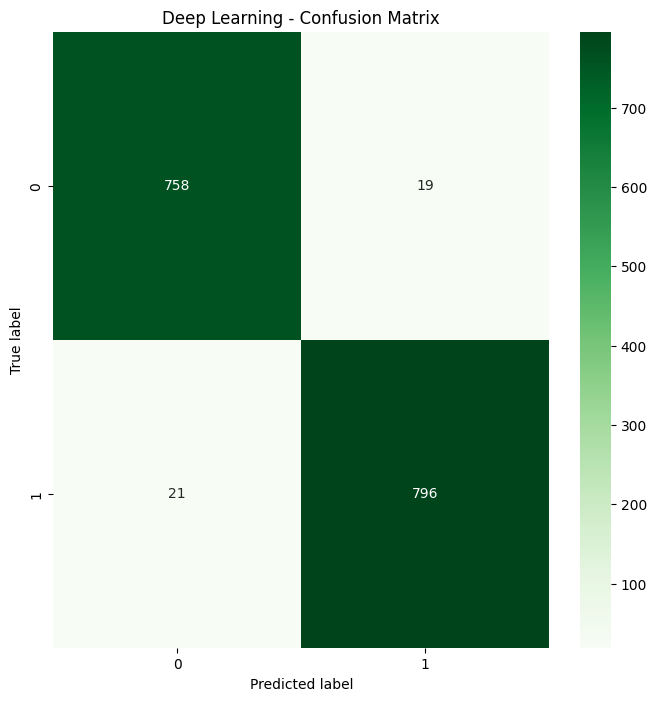

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report


# Predict on the Test Data
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype("int32").ravel()  # converte para vetor de 0/1

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
# Create a Confusion Matrix
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Deep Learning - Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.savefig('matrix_confusion.png')
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(historico.history['precision'], label='Train')
plt.plot(historico.history['val_precision'], label='Validation')
plt.title('Precision During Training')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.savefig('precision_history.png')
plt.close()


plt.figure(figsize=(8, 6))
plt.plot(historico.history['recall'], label='Train')
plt.plot(historico.history['val_recall'], label='Validation')
plt.title('Recall During Training')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.savefig('recall_history.png')
plt.close()

plt.figure(figsize=(8, 6))
plt.plot(historico.history['binary_accuracy'], label='Train')
plt.plot(historico.history['val_binary_accuracy'], label='Validation')
plt.title('Accuracy During Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('accuracy_history.png')
plt.close()

plt.figure(figsize=(8, 6))
plt.plot(historico.history['loss'], label='Train')
plt.plot(historico.history['val_loss'], label='Validation')
plt.title('Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('loss_history.png')
plt.close()


plt.figure(figsize=(8, 6))
corr_matrix = dataset[numeric_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Numeric Variables")
plt.savefig('correlation_matrix.png')
plt.close()

print("\nSuccessfully added 'precision' metric and generated the corresponding plot.")


Successfully added 'precision' metric and generated the corresponding plot.
